In [46]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

df = pd.read_csv('train.csv')
df.head() 

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


## UNDERSTANDING DATA

In [47]:
df.shape

(690088, 15)

690088 rows and 15 colums in dataset

In [48]:
df.describe()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,690088.00000,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,345043.50000,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,199211.39062,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,0.00000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,172521.75000,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,345043.50000,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,517565.25000,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,690087.00000,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


difference in counts means data is incomplete

In [49]:
df.describe(include='object')

C:\Users\ssa56\AppData\Local\Temp\ipykernel_11628\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,health_condition,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
count,690088,683187,607277,631757,653467,661506,668715
unique,3,3,3,3,3,3,3
top,at-risk,veg,medium,average,moderate,yes,male
freq,592561,231432,261819,213948,221041,223730,237756


In [50]:
df.dtypes

id                           int64
health_condition               str
sleep_duration             float64
heart_rate                 float64
bmi                        float64
calorie_expenditure        float64
step_count                 float64
exercise_duration          float64
water_intake               float64
diet_type                      str
stress_level                   str
sleep_quality                  str
physical_activity_level        str
smoking_alcohol                str
gender                         str
dtype: object

data types are already fixed

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  str    
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  str    
 10  stress_level             607277 non-null  str    
 11  sleep_quality            631757 non-null  str    
 12  physical_activity_level  653467 non-null  str    
 13  smoking_alcohol          661506 non-null  str    
 14  gender         

In [52]:
df.isnull().sum()

id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

we see lot of null values

In [53]:
df.duplicated().sum()

np.int64(0)

no duplicates found

In [54]:
df.nunique()

id                         690088
health_condition                3
sleep_duration                701
heart_rate                    537
bmi                          1596
calorie_expenditure          2101
step_count                  12807
exercise_duration             856
water_intake                  400
diet_type                       3
stress_level                    3
sleep_quality                   3
physical_activity_level         3
smoking_alcohol                 3
gender                          3
dtype: int64

the ones with 3 are categorical usually. numeric ones tells us the distribution

## CLEANING DATA

In [55]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object','category']).columns
print(numerical_cols)
print(categorical_cols)

Index(['id', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
       'step_count', 'exercise_duration', 'water_intake'],
      dtype='str')
Index(['health_condition', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender'],
      dtype='str')


C:\Users\ssa56\AppData\Local\Temp\ipykernel_11628\1454862777.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object','category']).columns


we cant drop these tens of thousands of rows so we will do an imputation technique and to see which one, we will first visualize data. Also we can see those rows where lot of columns are null and can drop them

In [56]:
nullsCountPerRow = df.isnull().sum(axis=1)    #count nulls per row
print(nullsCountPerRow.value_counts().sort_index())

0    349623
1    248134
2     77311
3     13445
4      1479
5        87
6         9
Name: count, dtype: int64


349k rows have no null columns, 13k rows have 3 null columns, lets drop 5,6 ones

In [57]:
df_cleaned = df[nullsCountPerRow<5]
print(df.shape)
print(df_cleaned.shape)

(690088, 15)
(689992, 15)


now do visualization then imputation

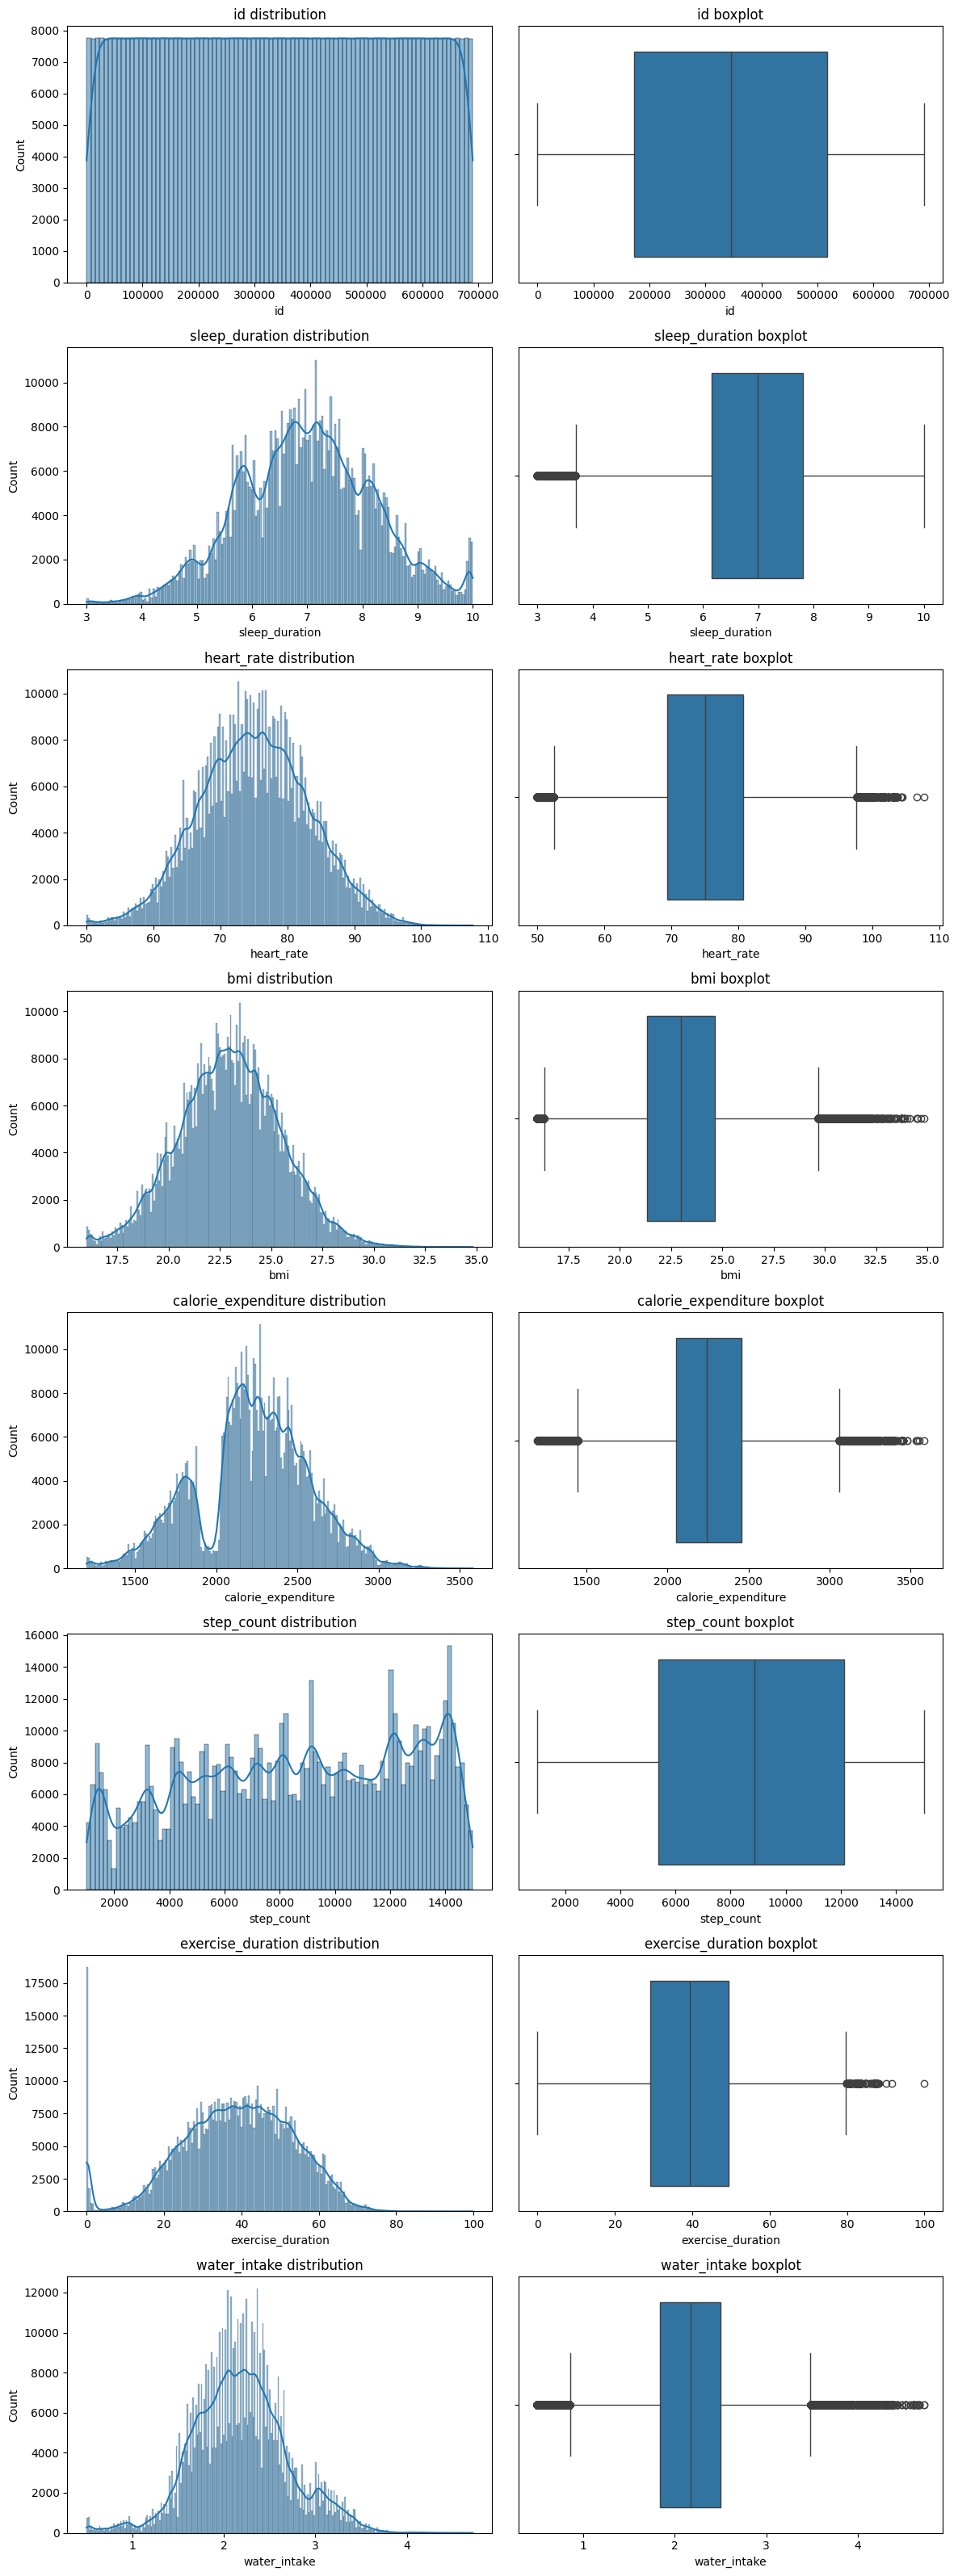

In [58]:
# for num cols
fig, axes = plt.subplots(len(numerical_cols),2,figsize=(12,4*len(numerical_cols)))
for i,col in enumerate(numerical_cols):
    sns.histplot(df_cleaned[col].dropna(), kde=True, ax=axes[i,0])
    axes[i,0].set_title(f'{col} distribution')
    sns.boxplot(x=df_cleaned[col], ax=axes[i,1])
    axes[i,1].set_title(f'{col} boxplot')
plt.tight_layout()
plt.show()

- sleep duration is bell shaped roughly = median imputation
- heart rate is normally distributed with few outliers = median imputation
- bmi also bell shaped with a right tailed and outliers = median imputation
- calories expenditure is bimodal (2 majod humps) = group median imputation
- step count is uniform = median imputation
- exercise duration has zero inflated pattern (a lot of 0 people who dont exercise) = later
- water intake is roughly normal = median imputation

In [60]:
from sklearn.impute import SimpleImputer
numColsImputed = numerical_cols.drop(['exercise_duration', 'calorie_expenditure'])
for col in numColsImputed:
    colSkew = df_cleaned[col].skew()
    print(col, "skew:", colSkew)
    if abs(colSkew) < 0.5:
        imputer = SimpleImputer(strategy='mean')
        df_cleaned[col] = imputer.fit_transform(df_cleaned[[col]])
    if abs(colSkew) >= 0.5:
        imputer = SimpleImputer(strategy='median')
        df_cleaned[col] = imputer.fit_transform(df_cleaned[[col]])

id skew: -1.6005297375464944e-05
sleep_duration skew: -0.008228155048850326
heart_rate skew: 0.00045577615496347073
bmi skew: 0.02463366433369069
step_count skew: -0.18024176805518194
water_intake skew: 0.10993134037700196


fix calorie expenditure and then exercise duration

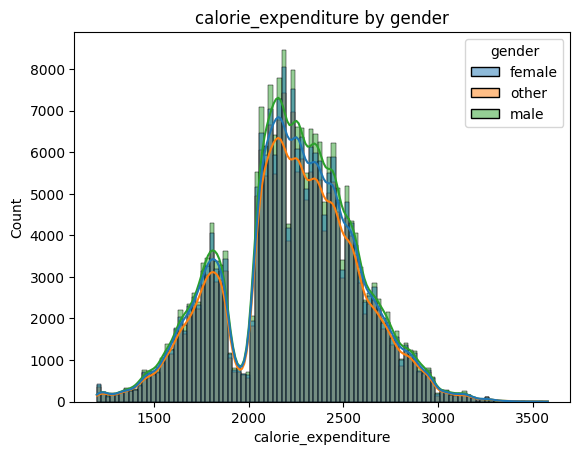

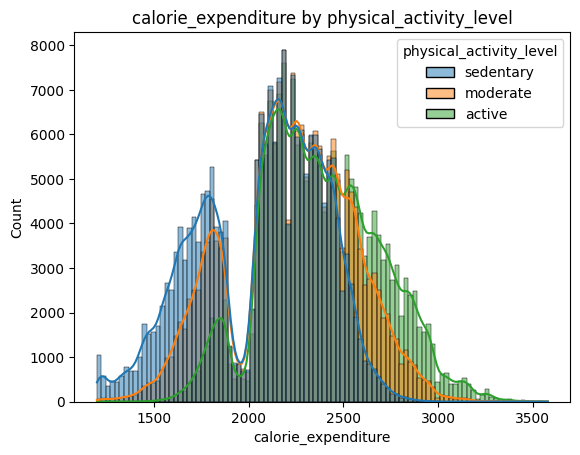

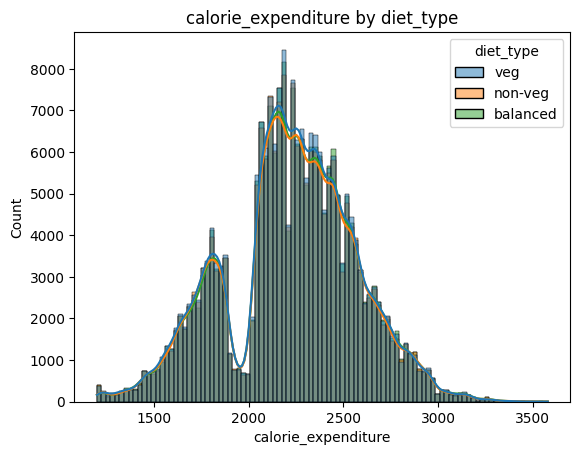

In [61]:
for col in ['gender', 'physical_activity_level', 'diet_type']:
    sns.histplot(data=df, x='calorie_expenditure', hue=col, kde=True, bins=100)
    plt.title(f'calorie_expenditure by {col}')
    plt.show()

none of these 3 columns explain the split. just use the median imputation

In [62]:
imputer = SimpleImputer(strategy='median')
df_cleaned['calorie_expenditure'] = imputer.fit_transform(df_cleaned[['calorie_expenditure']])

now fix exercise duration: since lot of it are 0 and lot if are value we fill 30% of missing values as 0 and 70% as median

In [67]:
np.random.seed(42)  # keeps results consistent every time you rerun
# your chosen values
zero_ratio = 0.30
median_value = df_cleaned['exercise_duration'].median()  # or nonzero median if you prefer

missing_mask = df_cleaned['exercise_duration'].isnull()
n_missing = missing_mask.sum()
# randomly fill missing values: 30% become 0, 70% become median
fill_values = np.random.choice([0, median_value], size=n_missing, p=[zero_ratio, 1 - zero_ratio])
df_cleaned.loc[missing_mask, 'exercise_duration'] = fill_values

In [64]:
for col in categorical_cols:
    print(df_cleaned[col].value_counts(dropna=False))
    print()

health_condition
at-risk      592477
unhealthy     57718
fit           39797
Name: count, dtype: int64

diet_type
veg         231404
balanced    226863
non-veg     224838
NaN           6887
Name: count, dtype: int64

stress_level
medium    261809
high      177741
low       167696
NaN        82746
Name: count, dtype: int64

sleep_quality
average    213936
poor       212158
good       205625
NaN         58273
Name: count, dtype: int64

physical_activity_level
moderate     221028
sedentary    219763
active       212628
NaN           36573
Name: count, dtype: int64

smoking_alcohol
yes           223725
no            219778
occasional    217952
NaN            28537
Name: count, dtype: int64

gender
male      237744
female    223977
other     206928
NaN        21343
Name: count, dtype: int64



in all columns, no option dominates others 2 so we cant replace with mode, best case is we add another category as missing

In [65]:
for col in categorical_cols:
    df_cleaned[col] = df_cleaned[col].fillna('Missing')

lets verify if data is filled by imputation

In [68]:
print(df_cleaned.isnull().sum())

id                         0
health_condition           0
sleep_duration             0
heart_rate                 0
bmi                        0
calorie_expenditure        0
step_count                 0
exercise_duration          0
water_intake               0
diet_type                  0
stress_level               0
sleep_quality              0
physical_activity_level    0
smoking_alcohol            0
gender                     0
dtype: int64


In [69]:
df=df_cleaned